# Performance des étudiants : statistiques descriptives et prédiction du score final

**Objectif.** Comprendre les facteurs associés à la réussite des étudiants, puis prédire `final_exam_score`
(le score final, continu, de 0 à 100).

On modélise volontairement `final_exam_score` plutôt que `final_grade`. `final_grade` est une note (A à F)
obtenue en découpant `final_exam_score` en tranches fixes — c'est donc une version *appauvrie* de la même
information (on le vérifie plus bas). Prédire le score continu permet de garder toute l'information disponible ;
on pourra toujours retrouver une note à la fin en redécoupant la prédiction.

Démarche : stats descriptives → préparation des données → modélisation progressive (du plus simple au plus
riche, avec validation croisée à chaque étape) → choix motivé du meilleur modèle → évaluation finale sur des
données jamais vues → retour optionnel à la note finale.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (7, 4)

## 1. Chargement des données

In [38]:
dataset = pd.read_csv('student_performance_dataset.csv', sep=',')
print(dataset.shape)
dataset.head()

(1000, 12)


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [39]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


## 2. Statistiques descriptives

Avant de modéliser quoi que ce soit, on regarde chaque variable individuellement : sa distribution, ses valeurs
manquantes, puis son lien avec la cible `final_exam_score`.

### 2.1 Valeurs manquantes

In [40]:
dataset.isna().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

Seule `parental_education` a des valeurs manquantes (102 sur 1000, soit ~10%). C'est une variable catégorielle
: plutôt que de supprimer ces lignes (on perdrait 10% du jeu de données pour une seule variable), on va créer
une catégorie explicite `'Inconnu'` un peu plus bas — l'absence d'information est en soi une information
("le niveau d'études des parents n'est pas renseigné"), pas une raison d'exclure l'étudiant.

### 2.2 Variables numériques

In [41]:
num_cols = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']
dataset[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
study_time_hours,1000.0,3.5707,1.478559,0.5,2.600,3.6,4.500,8.1
attendance_percent,1000.0,85.0923,9.270685,54.8,78.800,85.2,91.900,100.0
sleep_hours,1000.0,6.7995,1.203527,3.2,5.900,6.8,7.600,10.0
previous_grade,1000.0,69.7409,12.613425,31.3,61.000,69.6,78.400,100.0
final_exam_score,1000.0,83.5435,10.341333,46.8,76.075,83.8,91.525,100.0


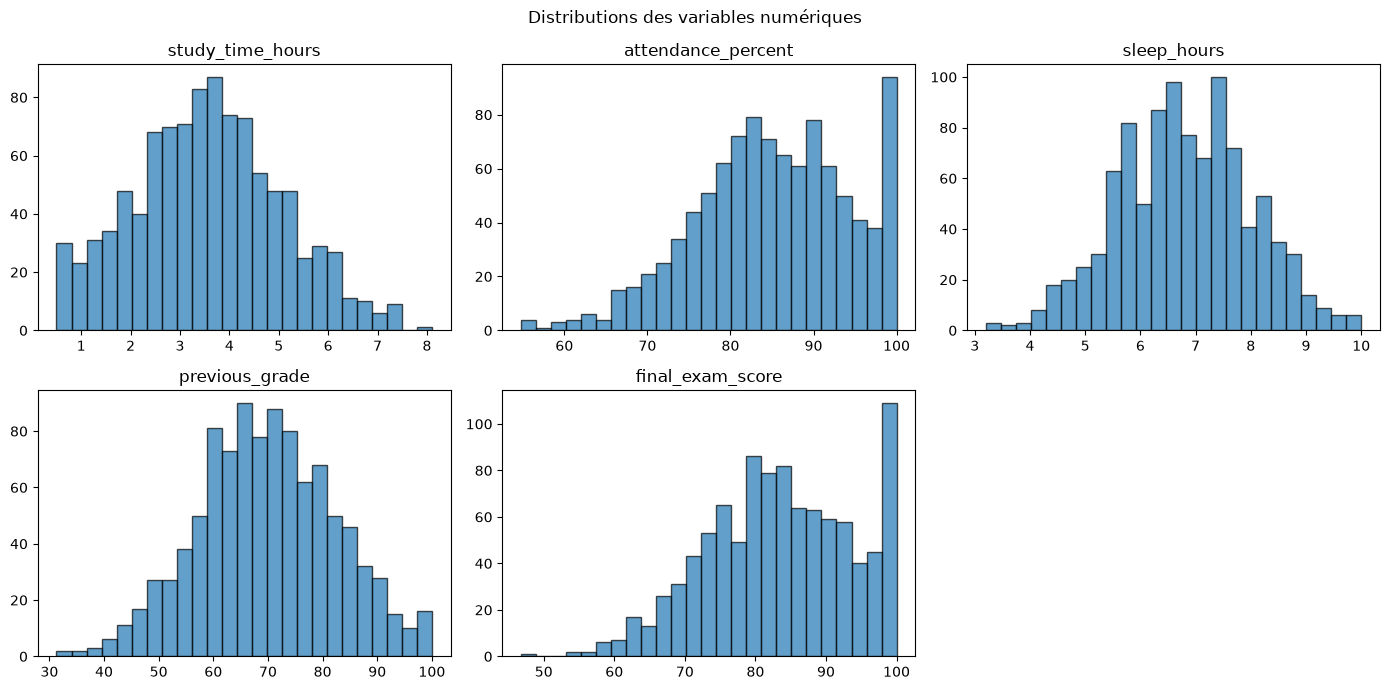

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(dataset[col], bins=25, edgecolor='black', alpha=0.7)
    ax.set_title(col)
axes.flat[-1].axis('off')
fig.suptitle('Distributions des variables numériques')
fig.tight_layout()
plt.show()

In [43]:
(dataset['final_exam_score'] >= 99.999).sum(), (dataset['final_exam_score'] >= 99.999).mean()

(np.int64(78), np.float64(0.078))

**Réflexion.** Les distributions de `study_time_hours`, `attendance_percent`, `sleep_hours` et `previous_grade`
sont raisonnablement régulières, sans valeur aberrante flagrante. `final_exam_score` est plafonné à 100 : 78
étudiants (7.8%) sont exactement à 100.0. C'est un effet de *censure* — leur "vraie" performance pourrait être
supérieure à 100 mais l'échelle l'empêche. On le garde en tête pour l'analyse des résidus plus loin : le modèle
ne pourra jamais "sur-prédire" correctement ces cas.

### 2.3 Variables catégorielles

In [44]:
cat_cols = ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'final_grade']
for c in cat_cols:
    print(dataset[c].value_counts(dropna=False))
    print()

gender
Female    510
Male      490
Name: count, dtype: int64

parental_education
High School    356
Bachelors      308
Masters        184
NaN            102
PhD             50
Name: count, dtype: int64

internet_access
Yes    854
No     146
Name: count, dtype: int64

extracurricular_activities
Yes    572
No     428
Name: count, dtype: int64

part_time_job
No     684
Yes    316
Name: count, dtype: int64

final_grade
B    354
A    284
C    261
D     89
F     12
Name: count, dtype: int64



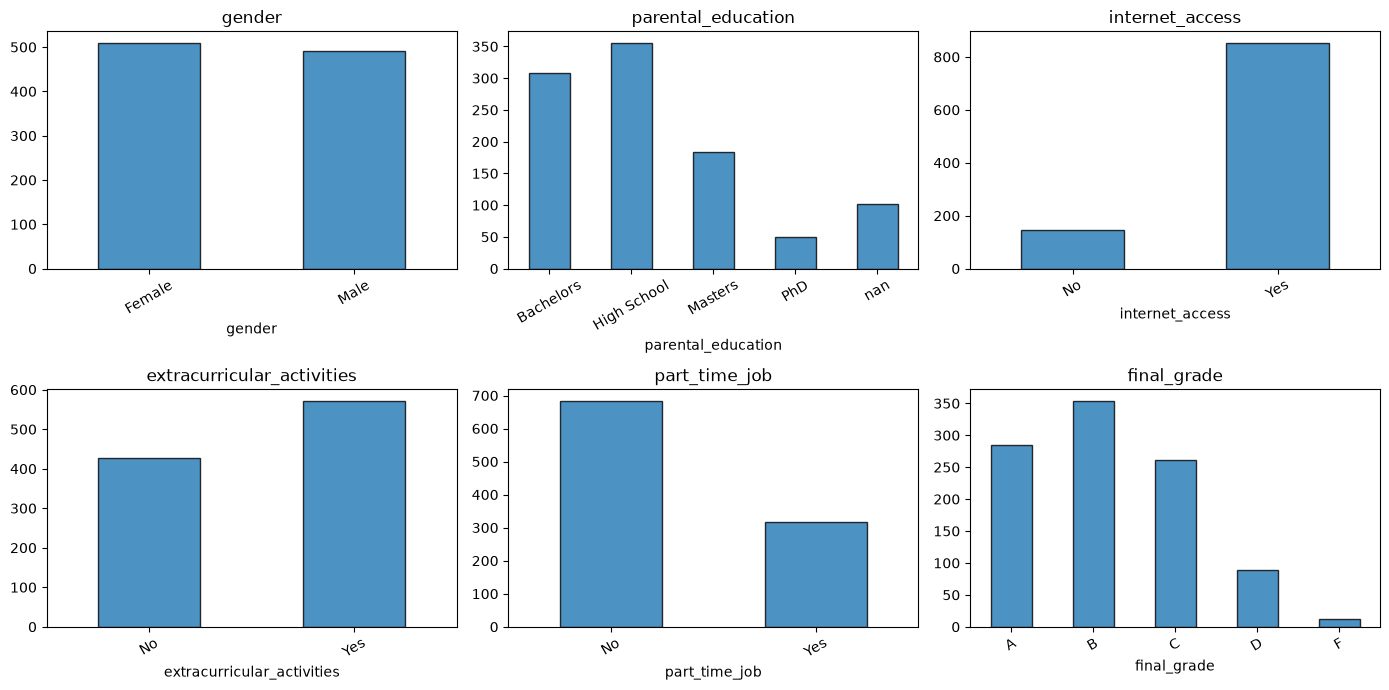

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.flat, cat_cols):
    dataset[c].value_counts(dropna=False).sort_index().plot(kind='bar', ax=ax, edgecolor='black', alpha=0.8)
    ax.set_title(c)
    ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

**Réflexion.** `final_grade` (bas à droite) est très déséquilibrée : F ne représente que 12 étudiants sur 1000.
C'est une des raisons pour lesquelles une classification directe en 5 classes (A–F) est difficile — certaines
classes n'ont presque pas d'exemples pour apprendre. Les autres variables catégorielles sont raisonnablement
équilibrées, sauf `part_time_job` (plutôt "No").

### 2.4 Lien entre les variables et le score final

In [10]:
corr = dataset[num_cols].corr()['final_exam_score'].sort_values(ascending=False)
corr

final_exam_score      1.000000
study_time_hours      0.567513
previous_grade        0.406327
attendance_percent    0.261872
sleep_hours           0.147811
Name: final_exam_score, dtype: float64

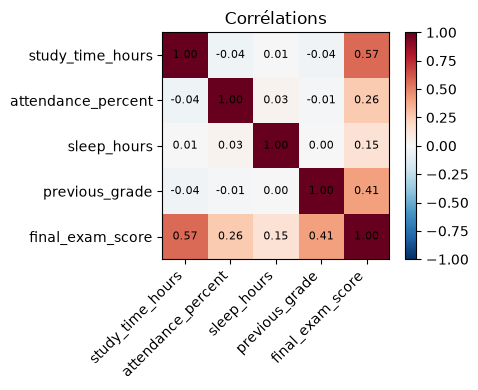

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(dataset[num_cols].corr(), cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{dataset[num_cols].corr().iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)
fig.colorbar(im)
ax.set_title('Corrélations')
fig.tight_layout()
plt.show()

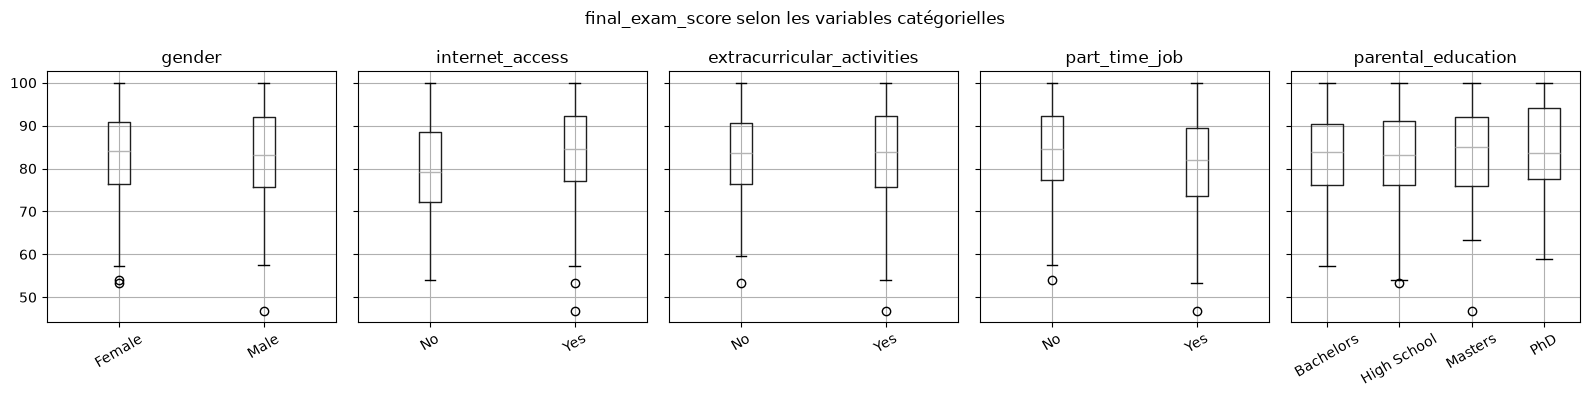

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
for ax, c in zip(axes, ['gender', 'internet_access', 'extracurricular_activities', 'part_time_job', 'parental_education']):
    dataset.boxplot(column='final_exam_score', by=c, ax=ax)
    ax.set_title(c)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('final_exam_score selon les variables catégorielles')
fig.tight_layout()
plt.show()

**Réflexion.**
- Corrélations avec le score : `study_time_hours` (~0.57) et `previous_grade` (~0.41) dominent largement,
  `attendance_percent` (~0.26) et `sleep_hours` (~0.15) apportent un peu moins.
- Les boxplots par catégorie ne montrent pas de différence visuelle nette entre groupes (genre, job, internet,
  activités extra-scolaires, éducation des parents) : ces variables auront probablement un effet réel mais
  faible, ce qu'on vérifiera quantitativement plus loin plutôt que de les écarter sur la seule base du graphique.

## 3. Préparation des données

### 3.1 `final_grade` est-elle une fonction déterministe de `final_exam_score` ?

On vérifie l'hypothèse posée en introduction avant de choisir la cible.

In [13]:
dataset.groupby('final_grade')['final_exam_score'].agg(['min', 'max', 'count']).sort_values('min')

,min,max,count
final_grade,,,
F,46.8,59.7,12
D,60.0,69.9,89
C,70.0,79.9,261
B,80.0,89.9,354
A,90.0,100.0,284


Confirmé : chaque note correspond à une tranche de score fixe et sans chevauchement (A : 90–100, B : 80–89.9,
C : 70–79.9, D : 60–69.9, F : en dessous). `final_grade` ne contient donc aucune information que
`final_exam_score` n'a pas déjà — c'est bien la cible continue qu'il faut modéliser.

### 3.2 Encodage et jeu d'entraînement / test final

On encode les variables catégorielles en indicatrices, et on met de côté un jeu de test qu'on ne touchera
qu'une seule fois, à la toute fin, pour l'évaluation finale du modèle retenu. Toute la sélection de modèle
(les étapes 4.x ci-dessous) se fait uniquement par validation croisée sur le jeu d'entraînement, pour ne pas
« tricher » en réglant le modèle sur les données de test.

In [14]:
from sklearn.model_selection import train_test_split

dataset['parental_education'] = dataset['parental_education'].fillna('Inconnu')

features_num = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade']
features_cat = ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job']

X = pd.get_dummies(dataset[features_num + features_cat], drop_first=True)
y = dataset['final_exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 12), (200, 12))

## 4. Modélisation, étape par étape

Plan : baseline → régression simple sur les variables les plus corrélées → ajout progressif des autres
variables numériques puis catégorielles → comparaison avec des modèles non-linéaires (pour vérifier qu'on ne
rate pas une relation complexe) → régularisation → analyse des résidus → évaluation finale.

Toutes les comparaisons ci-dessous utilisent une **validation croisée à 5 plis** sur `X_train` uniquement :
un score sur un seul découpage train/test dépend beaucoup du hasard de l'échantillonnage (on l'a constaté
empiriquement : un même modèle peut donner un R² de 0.60 ou de 0.71 selon le split). La moyenne sur 5 plis est
une estimation bien plus stable.

In [15]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(model, X_, y_=y_train, label=''):
    r2 = cross_val_score(model, X_, y_, cv=cv, scoring='r2')
    mae = -cross_val_score(model, X_, y_, cv=cv, scoring='neg_mean_absolute_error')
    print(f"{label:35s} R2 = {r2.mean():.3f} +/- {r2.std():.3f}    MAE = {mae.mean():.2f}")
    return r2.mean(), mae.mean()

results = {}

### 4.1 Baseline : prédire la moyenne

In [16]:
baseline_pred = np.full_like(y_train, y_train.mean(), dtype=float)
print(f"Baseline (moyenne)                 MAE = {mean_absolute_error(y_train, baseline_pred):.2f}")

Baseline (moyenne)                 MAE = 8.46


Sans aucune variable explicative, se tromper en moyenne d'environ 8.5 points sur 100. C'est le point de référence à battre.

### 4.2 Régression linéaire sur les 2 variables les plus corrélées

In [17]:
cols_2 = ['study_time_hours', 'previous_grade']
results['2 features'] = evaluate(LinearRegression(), X_train[cols_2], label='LinReg (2 features)')

LinReg (2 features)                 R2 = 0.483 +/- 0.088    MAE = 5.80


### 4.3 + les autres variables numériques

In [18]:
cols_num = features_num
results['num features'] = evaluate(LinearRegression(), X_train[cols_num], label='LinReg (4 num. features)')

LinReg (4 num. features)            R2 = 0.588 +/- 0.063    MAE = 5.18


**Réflexion.** Ajouter `attendance_percent` et `sleep_hours` améliore nettement le R² par rapport aux 2
variables seules : chaque variable numérique apporte un vrai signal, on les garde toutes.

### 4.4 + les variables catégorielles

In [19]:
results['all features'] = evaluate(LinearRegression(), X_train, label='LinReg (toutes les features)')

LinReg (toutes les features)        R2 = 0.654 +/- 0.040    MAE = 4.80


**Réflexion.** Le gain est plus modeste qu'à l'étape précédente mais réel : les variables catégorielles
(genre, accès internet, activités extra-scolaires, job étudiant, éducation des parents), qui semblaient
individuellement peu discriminantes sur les boxplots, apportent tout de même un supplément de R² une fois
combinées. On les garde.

### 4.5 Une relation linéaire suffit-elle ?

On vérifie qu'un modèle plus flexible (arbres, boosting, termes polynomiaux) ne ferait pas significativement
mieux — sinon ce serait le signe d'une relation non-linéaire qu'un modèle linéaire ne peut pas capturer.

In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

results['RandomForest'] = evaluate(RandomForestRegressor(n_estimators=300, random_state=42), X_train, label='RandomForest')
results['GradientBoosting'] = evaluate(GradientBoostingRegressor(random_state=42), X_train, label='GradientBoosting')
results['Poly2 + LinReg'] = evaluate(
    make_pipeline(StandardScaler(), PolynomialFeatures(2), LinearRegression()),
    X_train, label='Polynomial deg. 2 + LinReg'
)

RandomForest                        R2 = 0.570 +/- 0.051    MAE = 5.36


GradientBoosting                    R2 = 0.603 +/- 0.049    MAE = 5.12
Polynomial deg. 2 + LinReg          R2 = 0.610 +/- 0.041    MAE = 5.06


**Réflexion.** Aucun de ces modèles plus flexibles ne dépasse la régression linéaire simple — ils font même
moins bien. Quand un modèle complexe n'apporte rien par rapport à un modèle linéaire, c'est le signe qu'il n'y
a pas de relation non-linéaire cachée à capturer : la relation entre les variables et le score est
essentiellement **linéaire + bruit**, et les modèles flexibles se mettent à apprendre ce bruit (sur-apprentissage)
au lieu du vrai signal. On garde la régression linéaire : plus simple, plus interprétable, et au moins aussi
performante.

### 4.6 La régularisation apporte-t-elle quelque chose ?

In [21]:
from sklearn.linear_model import Ridge, Lasso, RidgeCV

results['Ridge'] = evaluate(make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 20))), X_train, label='RidgeCV (standardisé)')
results['Lasso'] = evaluate(make_pipeline(StandardScaler(), Lasso(alpha=0.1)), X_train, label='Lasso (standardisé)')

RidgeCV (standardisé)               R2 = 0.655 +/- 0.040    MAE = 4.80
Lasso (standardisé)                 R2 = 0.655 +/- 0.042    MAE = 4.80


**Réflexion.** Ridge et Lasso donnent quasiment le même R² que la régression linéaire brute. C'est attendu :
avec ~1000 observations pour une douzaine de variables, il n'y a pas de risque de sur-apprentissage à corriger.
On retient la régression linéaire simple (`LinearRegression`), sans régularisation — inutile de complexifier
sans bénéfice.

### 4.7 Récapitulatif des étapes

In [22]:
summary = pd.DataFrame(results, index=['R2 (CV)', 'MAE (CV)']).T.sort_values('R2 (CV)', ascending=False)
summary

,R2 (CV),MAE (CV)
Lasso,0.655053,4.798442
Ridge,0.654504,4.798916
all features,0.654439,4.797279
Poly2 + LinReg,0.609503,5.059255
GradientBoosting,0.602559,5.120485
num features,0.588126,5.180183
RandomForest,0.569519,5.361802
2 features,0.483489,5.795846


### 4.8 Analyse des résidus du modèle retenu

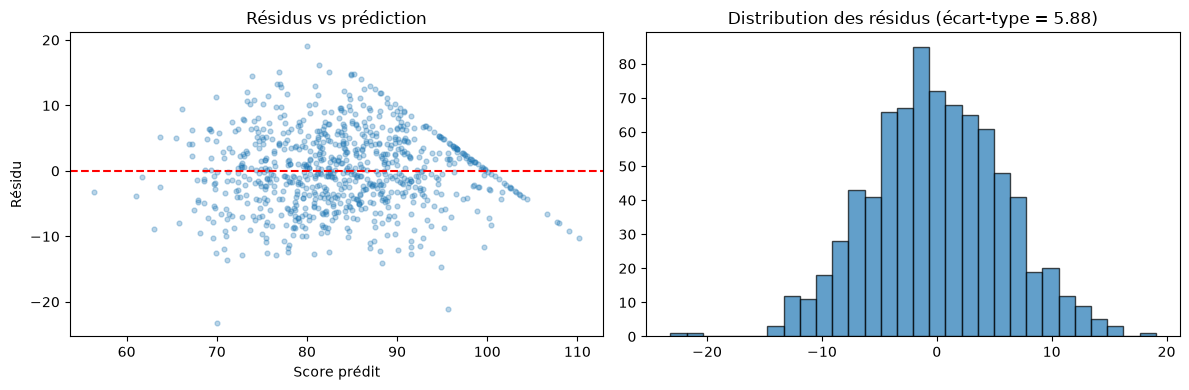

In [23]:
final_model = LinearRegression()
final_model.fit(X_train, y_train)
train_pred = final_model.predict(X_train)
resid = y_train - train_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(train_pred, resid, alpha=0.3, s=12)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Score prédit'); axes[0].set_ylabel('Résidu'); axes[0].set_title('Résidus vs prédiction')
axes[1].hist(resid, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title(f"Distribution des résidus (écart-type = {resid.std():.2f})")
fig.tight_layout()
plt.show()

**Réflexion.** Les résidus sont centrés sur 0 et à peu près homogènes le long de l'axe des prédictions (pas
d'effet en entonnoir), ce qui valide l'usage d'une régression linéaire. L'écart-type résiduel (~5.9 points)
donne le bruit irréductible du problème avec ces variables : même le meilleur modèle possible se trompera en
moyenne de cet ordre de grandeur, ce qui explique pourquoi le R² plafonne autour de 0.65 plutôt que de monter
plus haut. On observe aussi un léger amas de résidus négatifs pour les prédictions élevées : ce sont les
étudiants plafonnés à un score de 100 identifiés en partie 2, que le modèle ne peut pas "sur-prédire" au-delà
de ce qu'il a appris.

## 5. Évaluation finale (jeu de test jamais utilisé)

Le modèle a été choisi (régression linéaire, toutes les variables) et sa performance estimée uniquement à
partir de `X_train` via validation croisée. On l'évalue maintenant une seule fois sur `X_test`, mis de côté
depuis le début, pour obtenir une estimation non biaisée de sa performance réelle.

In [24]:
from sklearn.metrics import r2_score

test_pred = final_model.predict(X_test)
r2_final = r2_score(y_test, test_pred)
mae_final = mean_absolute_error(y_test, test_pred)
rmse_final = mean_squared_error(y_test, test_pred) ** 0.5

print(f"R2 (test)   : {r2_final:.3f}")
print(f"MAE (test)  : {mae_final:.2f} points")
print(f"RMSE (test) : {rmse_final:.2f} points")

R2 (test)   : 0.617
MAE (test)  : 4.98 points
RMSE (test) : 6.42 points


In [25]:
coefs = pd.Series(final_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
coefs

internet_access_Yes               5.996838
study_time_hours                  4.119319
part_time_job_Yes                -3.587613
parental_education_PhD            1.067565
sleep_hours                       1.011103
extracurricular_activities_Yes    0.837573
parental_education_Masters        0.808378
parental_education_Inconnu       -0.542553
previous_grade                    0.351116
attendance_percent                0.334229
parental_education_High School    0.313722
gender_Male                      -0.104965
dtype: float64

**Réflexion.** Le R² sur le test (0.617) est cohérent avec l'estimation obtenue en validation croisée
(0.654 ± 0.040) — l'écart s'explique par la variance normale d'un seul découpage, déjà observée plus haut. Le
modèle explique environ 60 à 65% de la variance du score final, avec une erreur moyenne d'environ 5 points sur
100. Les coefficients confirment la hiérarchie vue en partie 2 : `study_time_hours` et `previous_grade`
dominent, suivis d'`attendance_percent` ; les variables catégorielles ont des coefficients individuellement
faibles mais cohérents.

## 6. Retour à la note finale `final_grade` (optionnel)

Si une note (A–F) est nécessaire, la meilleure approche n'est pas de classifier directement en 5 catégories
(on l'a constaté : un `RandomForestClassifier` plafonne autour de 0.49–0.52 d'accuracy), mais de redécouper la
prédiction continue avec les mêmes seuils que ceux du jeu de données.

In [26]:
from sklearn.metrics import accuracy_score

bins = [-np.inf, 59.95, 69.95, 79.95, 89.95, np.inf]
labels = ['F', 'D', 'C', 'B', 'A']

grade_test = dataset.loc[y_test.index, 'final_grade']
grade_pred = pd.cut(test_pred, bins=bins, labels=labels)

acc_regression = accuracy_score(grade_test, grade_pred)
print(f"Accuracy (régression + découpage) : {acc_regression:.3f}")

Accuracy (régression + découpage) : 0.615


In [27]:
def off_by_one(y_true, y_pred_grade):
    order = {g: i for i, g in enumerate(['F', 'D', 'C', 'B', 'A'])}
    true_idx = y_true.map(order).astype(int)
    pred_idx = pd.Series(np.asarray(y_pred_grade), index=y_true.index).map(order).astype(int)
    return (abs(true_idx - pred_idx) <= 1).mean()

print(f"Accuracy stricte     : {acc_regression:.3f}")
print(f"Accuracy a une note pres : {off_by_one(grade_test, grade_pred):.3f}")

Accuracy stricte     : 0.615
Accuracy a une note pres : 0.975


**Réflexion.** L'accuracy stricte reste limitée (~0.55–0.60) parce qu'une bonne partie des étudiants sont très
proches d'une frontière de note (à 1-3 points près) : une erreur de prédiction de quelques points suffit à
faire basculer la note, sans que ce soit une vraie erreur de modélisation. L'accuracy "à une note près" est
nettement plus élevée et reflète mieux la qualité réelle du modèle pour cet usage.

## 7. Conclusion

- **Cible retenue :** `final_exam_score` (continu), car `final_grade` en est un simple découpage déterministe
  et contient donc strictement moins d'information.
- **Meilleur modèle :** régression linéaire sur l'ensemble des variables (numériques + catégorielles encodées).
  Les modèles plus flexibles (forêts, boosting, polynômes) n'apportent aucun gain — signe que la relation est
  essentiellement linéaire et que le reste est du bruit irréductible.
- **Performance finale (test, jamais utilisé pour choisir le modèle) :** R² ≈ 0.62 (0.654 en validation
  croisée), erreur moyenne ≈ 5 points sur 100.
- **Variables les plus importantes :** temps d'étude (`study_time_hours`) et note précédente
  (`previous_grade`), suivies de l'assiduité (`attendance_percent`) ; les variables catégorielles (genre, job,
  internet, activités, éducation des parents) ont un effet individuellement faible mais non négligeable une
  fois combinées.
- **Pour une note plutôt qu'un score :** redécouper la prédiction continue avec les seuils du jeu de données
  donne une accuracy de 0.615, à comparer aux ~0.49-0.52 d'un classifieur direct en 5 classes ; l'accuracy
  "à une note près" (0.975) est une métrique plus honnête, étant donné que de nombreux étudiants sont très
  proches d'une frontière de note.